# GVH Diagonal Cubic — RACC-C.4-real.2.8
## GW150914 H1/L1 — Nonstationarity Source Decomposition Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.8`  
**Noyau GVH Diagonal modifié : NON**

### Question falsifiable

La non-stationnarité observée dans `real.2.6–2.7` vient-elle principalement :

- du chirp lui-même ;
- d'une réponse relative H1/L1 ;
- du bruit/SNR ;
- du prétraitement ;
- de l'estimateur ;
- ou d'interactions entre plusieurs facteurs ?

On évite une décomposition additive imposée. On teste plutôt :

\[
\mathcal N_{\rm obs}=\mathcal F(C,D,N,P,E)
\]

où \(C,D,N,P,E\) représentent respectivement chirp, détecteur, bruit, preprocessing et estimateur.

### Méthode

Un facteur est modifié à la fois, avec les mêmes métriques locales :

\[
f_{\rm stable},\quad
f_{\rm transition},\quad
f_{\rm nonstable},\quad
f_{\rm unresolved},
\]

ainsi que :

\[
\mathrm{MAD}_{\phi},\qquad
\mathrm{CV}_{|T|}.
\]

### Stop-rule

Ce notebook ne certifie pas le timing.

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

La chaîne HH et `DISPERSION_READY` restent inchangées.


In [1]:

import os,sys,subprocess,importlib,json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

try: import lalframe
except Exception:
    pip_install("lalsuite"); importlib.invalidate_caches(); import lalframe

try: import gwpy
except Exception:
    pip_install("gwpy"); importlib.invalidate_caches(); import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import median_abs_deviation
from gwpy.timeseries import TimeSeries

RNG=np.random.default_rng(20260812)
print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement des données réelles

In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists(): hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("H1/L1 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")

h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)

print(H1.name)
print(L1.name)
print("N =",len(h1),"fs =",fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Prétraitements et fenêtre événement

In [3]:

NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))
EVENT=(-.16,.08)
em=(t_rel>=EVENT[0])&(t_rel<=EVENT[1])

def center(x):
    return np.asarray(x,float)-np.mean(x)

def whiten(x):
    x=center(x)
    n=len(x)
    f=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    fp,P=signal.welch(x[NOISE],fs=fs,nperseg=4096)
    Pi=np.interp(f,fp,P,left=P[0],right=P[-1])
    floor=np.finfo(float).eps*np.max(Pi)
    y=np.fft.irfft(X/np.sqrt(Pi+floor),n=n)
    return y/np.std(y[NOISE])

def bandpass(x,lo=35,hi=350,order=4):
    sos=signal.butter(order,[lo,hi],btype="bandpass",fs=fs,output="sos")
    return signal.sosfiltfilt(sos,center(x))

def notch(x):
    y=np.asarray(x,float).copy()
    for f0 in [60,120,180,240,300]:
        b,a=signal.iirnotch(f0,Q=30,fs=fs)
        y=signal.filtfilt(b,a,y)
    return y

H_real=notch(bandpass(whiten(h1)))[em]
L_real=notch(bandpass(whiten(l1)))[em]

print("event samples:",len(H_real))


event samples: 983


## 3 — Mesure commune de non-stationnarité

Chaque scénario est converti en STFT et en transfert empirique local :

\[
T(f,t)=\frac{L(f,t)H^*(f,t)}{|H(f,t)|^2+\epsilon}.
\]

On utilise exactement la même classification locale pour tous les scénarios.


In [4]:

def nonstationarity_metrics(H,L,nper=256,nover=224):
    f,t,Zh=signal.stft(H,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)
    _,_,Zl=signal.stft(L,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)

    eps=np.finfo(float).eps
    T=(Zl*np.conj(Zh))/(np.abs(Zh)**2+eps)
    power=np.abs(Zh)*np.abs(Zl)
    band=(f>=40)&(f<=300)
    P=power[band,:]

    if P.size==0:
        return None

    P70=np.quantile(P,.70)
    P40=np.quantile(P,.40)

    rows=[]
    valid_f=np.where(band)[0]
    for j,tj in enumerate(t):
        for i in valid_f:
            rows.append({
                "t":float(tj),"f":float(f[i]),
                "amp":float(np.abs(T[i,j])),
                "phase":float(np.angle(T[i,j])),
                "power":float(power[i,j]),
                "snr_class":"low" if power[i,j]<P40 else ("medium" if power[i,j]<P70 else "high")
            })

    tiles=pd.DataFrame(rows)
    times=np.sort(tiles.t.unique())
    freqs=np.sort(tiles.f.unique())
    grid=tiles.set_index(["t","f"])
    local=[]

    for ti,tv in enumerate(times):
        for fi,fv in enumerate(freqs):
            if (tv,fv) not in grid.index: continue
            tn=times[max(0,ti-1):min(len(times),ti+2)]
            fn=freqs[max(0,fi-1):min(len(freqs),fi+2)]
            vals=[]
            for a in tn:
                for b in fn:
                    if (a,b) in grid.index:
                        r=grid.loc[(a,b)]
                        vals.append((r.amp,r.phase,r.power))
            if len(vals)<4: continue

            amp=np.array([v[0] for v in vals])
            ph=np.unwrap(np.array([v[1] for v in vals]))
            pw=np.array([v[2] for v in vals])

            am=np.median(amp)
            amp_cv=np.median(np.abs(amp-am))/(abs(am)+1e-12)
            pm=np.median(ph)
            phase_mad=np.median(np.abs(ph-pm))

            z=amp*np.exp(1j*ph)
            z0=np.average(z,weights=pw)
            complex_dist=np.median(np.abs(z-z0))/(np.median(np.abs(z))+1e-12)

            r0=grid.loc[(tv,fv)]
            if r0.snr_class=="low":
                regime="UNRESOLVED_LOW_SNR"
            elif amp_cv<.20 and phase_mad<.40 and complex_dist<.20:
                regime="STABLE"
            elif amp_cv>.40 or phase_mad>1.00 or complex_dist>.40:
                regime="NONSTABLE"
            else:
                regime="TRANSITION"

            local.append({
                "amp_cv":amp_cv,
                "phase_mad":phase_mad,
                "complex_dist":complex_dist,
                "regime":regime
            })

    d=pd.DataFrame(local)
    if len(d)==0:
        return None

    resolved=d[d.regime!="UNRESOLVED_LOW_SNR"]
    counts=d.regime.value_counts()
    rc=resolved.regime.value_counts()
    nr=len(resolved)

    return {
        "n_tiles":len(d),
        "resolved_fraction":len(resolved)/len(d),
        "stable_fraction_resolved":rc.get("STABLE",0)/nr if nr else np.nan,
        "transition_fraction_resolved":rc.get("TRANSITION",0)/nr if nr else np.nan,
        "nonstable_fraction_resolved":rc.get("NONSTABLE",0)/nr if nr else np.nan,
        "unresolved_fraction":counts.get("UNRESOLVED_LOW_SNR",0)/len(d),
        "median_amp_cv":float(np.nanmedian(d.amp_cv)),
        "median_phase_mad":float(np.nanmedian(d.phase_mad)),
        "median_complex_dist":float(np.nanmedian(d.complex_dist))
    }


## 4 — C0 : baseline réelle

In [5]:

scenarios={}
scenarios["C0_REAL_BASELINE"]=(H_real,L_real)
baseline=nonstationarity_metrics(H_real,L_real)
display(pd.DataFrame([baseline]))


,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,384,0.598958,0.013043,0.104348,0.882609,0.401042,0.346865,0.623665,0.732673


## 5 — C1 : signal stationnaire large bande synthétique

In [6]:

n=len(H_real)
white=RNG.normal(size=n)
sos=signal.butter(6,[40,300],btype="bandpass",fs=fs,output="sos")
s=signal.sosfiltfilt(sos,white)
s/=np.std(s)

# Same stationary signal in both channels, independent mild noise.
H1s=s+0.05*RNG.normal(size=n)
L1s=s+0.05*RNG.normal(size=n)

scenarios["C1_STATIONARY_SYNTH"]=(H1s,L1s)


## 6 — C2 : chirp synthétique identique dans A/B

In [7]:

tt=np.arange(n)/fs
chirp=signal.chirp(tt,f0=35,f1=320,t1=max(tt[-1],1/fs),method="quadratic")
chirp*=signal.windows.tukey(n,.15)

H2=chirp+0.05*RNG.normal(size=n)
L2=chirp+0.05*RNG.normal(size=n)

scenarios["C2_CHIRP_ONLY"]=(H2,L2)


## 7 — C3 : chirp + transfert stationnaire connu

In [8]:

f=np.fft.rfftfreq(n,1/fs)
Hf=np.fft.rfft(chirp)

# Fixed smooth amplitude/phase response, explicitly time-stationary.
Afix=1.0+0.20*(f/350.0)
phfix=0.35+0.0015*f
Tfix=Afix*np.exp(1j*phfix)

L3=np.fft.irfft(Hf*Tfix,n=n)
H3=chirp+0.05*RNG.normal(size=n)
L3=L3+0.05*RNG.normal(size=n)

scenarios["C3_CHIRP_FIXED_TRANSFER"]=(H3,L3)


## 8 — C4 : chirp + transfert non stationnaire injecté

In [9]:

# Piecewise time-varying transfer as a controlled positive test.
third=n//3
H4=chirp.copy()
L4=np.zeros_like(chirp)

for k,(a,b) in enumerate([(0,third),(third,2*third),(2*third,n)]):
    seg=chirp[a:b]
    ff=np.fft.rfftfreq(len(seg),1/fs)
    Sf=np.fft.rfft(seg)
    amp=1.0+0.12*k+0.08*(ff/350)
    phase=(0.15+0.55*k)+(0.0008+0.0010*k)*ff
    Tk=amp*np.exp(1j*phase)
    L4[a:b]=np.fft.irfft(Sf*Tk,n=len(seg))

H4+=0.05*RNG.normal(size=n)
L4+=0.05*RNG.normal(size=n)

scenarios["C4_CHIRP_TIMEVARYING_TRANSFER"]=(H4,L4)


## 9 — C5 : contribution bruit/SNR

In [10]:

# Same chirp and fixed transfer, multiple noise levels.
for noise_sigma in [0.0,0.02,0.05,0.10,0.20]:
    Hn=chirp+noise_sigma*RNG.normal(size=n)
    Ln=np.fft.irfft(Hf*Tfix,n=n)+noise_sigma*RNG.normal(size=n)
    scenarios[f"C5_NOISE_{noise_sigma:.2f}"]=(Hn,Ln)


## 10 — C6 : dépendance au prétraitement réel

In [11]:

# Raw-ish alternatives built from the same real event.
H_bp=bandpass(h1)[em]
L_bp=bandpass(l1)[em]

H_bp_notch=notch(H_bp)
L_bp_notch=notch(L_bp)

H_white=bandpass(whiten(h1))[em]
L_white=bandpass(whiten(l1))[em]

scenarios["C6_REAL_BP"]=(H_bp,L_bp)
scenarios["C6_REAL_BP_NOTCH"]=(H_bp_notch,L_bp_notch)
scenarios["C6_REAL_WHITEN_BP"]=(H_white,L_white)
scenarios["C6_REAL_WHITEN_BP_NOTCH"]=(H_real,L_real)


## 11 — Évaluation uniforme de tous les scénarios

In [12]:

rows=[]
for name,(A,B) in scenarios.items():
    met=nonstationarity_metrics(A,B)
    if met is None:
        rows.append({"scenario":name,"status":"FAILED"})
    else:
        row={"scenario":name,"status":"OK"}
        row.update(met)
        rows.append(row)

scenario_df=pd.DataFrame(rows)
display(scenario_df)


,scenario,status,n_tiles,resolved_fraction,stable_fraction_resolved,transition_fraction_resolved,nonstable_fraction_resolved,unresolved_fraction,median_amp_cv,median_phase_mad,median_complex_dist
0,C0_REAL_BASELINE,OK,384,0.598958,0.013043,0.104348,0.882609,0.401042,3.468651e-01,0.623665,7.326728e-01
1,C1_STATIONARY_SYNTH,OK,384,0.598958,1.000000,0.000000,0.000000,0.401042,1.021481e-02,0.011142,1.959316e-02
2,C2_CHIRP_ONLY,OK,384,0.598958,0.660870,0.091304,0.247826,0.401042,1.907632e-01,0.255596,4.869782e-01
3,C3_CHIRP_FIXED_TRANSFER,OK,384,0.598958,0.700000,0.108696,0.191304,0.401042,1.565552e-01,0.236212,3.692276e-01
4,C4_CHIRP_TIMEVARYING_TRANSFER,OK,384,0.598958,0.456522,0.173913,0.369565,0.401042,2.435785e-01,0.370542,5.736677e-01
5,C5_NOISE_0.00,OK,384,0.598958,1.000000,0.000000,0.000000,0.401042,9.324477e-03,0.010692,1.803643e-02
6,C5_NOISE_0.02,OK,384,0.598958,0.773913,0.108696,0.117391,0.401042,1.544203e-01,0.152400,2.849312e-01
7,C5_NOISE_0.05,OK,384,0.598958,0.660870,0.117391,0.221739,0.401042,1.459145e-01,0.236900,3.902492e-01
8,C5_NOISE_0.10,OK,384,0.598958,0.565217,0.139130,0.295652,0.401042,1.954565e-01,0.301629,5.247759e-01
9,C5_NOISE_0.20,OK,384,0.598958,0.465217,0.139130,0.395652,0.401042,2.386526e-01,0.347472,5.536701e-01


## 12 — Effets principaux relatifs à la baseline réelle

In [13]:

base_non=float(scenario_df.loc[scenario_df.scenario=="C0_REAL_BASELINE","nonstable_fraction_resolved"].iloc[0])

scenario_df["delta_nonstable_vs_real"]=scenario_df["nonstable_fraction_resolved"]-base_non

# Key comparisons
def val(name,col):
    z=scenario_df.loc[scenario_df.scenario==name,col]
    return float(z.iloc[0]) if len(z) else np.nan

stationary_non=val("C1_STATIONARY_SYNTH","nonstable_fraction_resolved")
chirp_non=val("C2_CHIRP_ONLY","nonstable_fraction_resolved")
fixed_non=val("C3_CHIRP_FIXED_TRANSFER","nonstable_fraction_resolved")
vary_non=val("C4_CHIRP_TIMEVARYING_TRANSFER","nonstable_fraction_resolved")

print("real baseline nonstable =",base_non)
print("stationary synth =",stationary_non)
print("chirp only =",chirp_non)
print("chirp fixed transfer =",fixed_non)
print("chirp varying transfer =",vary_non)


real baseline nonstable = 0.8826086956521739
stationary synth = 0.0
chirp only = 0.24782608695652175
chirp fixed transfer = 0.19130434782608696
chirp varying transfer = 0.3695652173913043


## 13 — Sensibilité au bruit

,noise_sigma,nonstable_fraction_resolved,stable_fraction_resolved,median_phase_mad,median_amp_cv
5,0.00,0.000000,1.000000,0.010692,0.009324
6,0.02,0.117391,0.773913,0.152400,0.154420
7,0.05,0.221739,0.660870,0.236900,0.145914
8,0.10,0.295652,0.565217,0.301629,0.195457
9,0.20,0.395652,0.465217,0.347472,0.238653


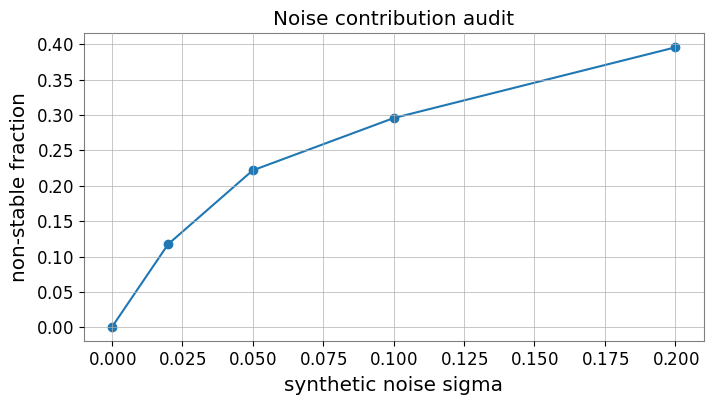

In [14]:

noise_df=scenario_df[scenario_df.scenario.str.startswith("C5_NOISE_")].copy()
noise_df["noise_sigma"]=noise_df.scenario.str.replace("C5_NOISE_","",regex=False).astype(float)
noise_df=noise_df.sort_values("noise_sigma")
display(noise_df[["noise_sigma","nonstable_fraction_resolved","stable_fraction_resolved",
                  "median_phase_mad","median_amp_cv"]])

plt.figure(figsize=(8,4))
plt.plot(noise_df.noise_sigma,noise_df.nonstable_fraction_resolved,marker="o")
plt.xlabel("synthetic noise sigma")
plt.ylabel("non-stable fraction")
plt.title("Noise contribution audit")
plt.grid(True)
plt.show()


## 14 — Sensibilité au prétraitement

In [15]:

prep_df=scenario_df[scenario_df.scenario.str.startswith("C6_REAL_")].copy()
display(prep_df[["scenario","nonstable_fraction_resolved","stable_fraction_resolved",
                 "median_phase_mad","median_amp_cv"]])

prep_span=float(
    prep_df.nonstable_fraction_resolved.max()-
    prep_df.nonstable_fraction_resolved.min()
) if len(prep_df) else np.nan

print("preprocessing nonstable span =",prep_span)


,scenario,nonstable_fraction_resolved,stable_fraction_resolved,median_phase_mad,median_amp_cv
10,C6_REAL_BP,0.126087,0.534783,0.436551,1.633100e-18
11,C6_REAL_BP_NOTCH,0.156522,0.400000,0.621262,9.245073e-19
12,C6_REAL_WHITEN_BP,0.882609,0.004348,0.538155,3.525881e-01
13,C6_REAL_WHITEN_BP_NOTCH,0.882609,0.013043,0.623665,3.468651e-01


preprocessing nonstable span = 0.7565217391304349


## 15 — Attribution opérationnelle

Cette attribution est **comparative**, pas une loi additive.

On cherche quel facteur produit les plus grands changements contrôlés de \(f_{\rm nonstable}\).


In [16]:

effects={}

# Chirp contribution relative to stationary synthetic.
effects["chirp_effect"]=chirp_non-stationary_non

# Fixed detector-like transfer contribution relative to chirp only.
effects["fixed_transfer_effect"]=fixed_non-chirp_non

# Explicit time-varying transfer contribution.
effects["timevarying_transfer_effect"]=vary_non-fixed_non

# Noise effect = span across controlled noise sweep.
effects["noise_effect"]=float(noise_df.nonstable_fraction_resolved.max()-
                              noise_df.nonstable_fraction_resolved.min()) if len(noise_df) else np.nan

# Preprocessing effect = real-data preprocessing span.
effects["preprocessing_effect"]=prep_span

effect_df=pd.DataFrame([
    {"factor":k,"effect_size":v,"abs_effect":abs(v) if np.isfinite(v) else np.nan}
    for k,v in effects.items()
]).sort_values("abs_effect",ascending=False)

display(effect_df)


,factor,effect_size,abs_effect
4,preprocessing_effect,0.756522,0.756522
3,noise_effect,0.395652,0.395652
0,chirp_effect,0.247826,0.247826
2,timevarying_transfer_effect,0.178261,0.178261
1,fixed_transfer_effect,-0.056522,0.056522


## 16 — Classification finale

In [17]:

finite_effects=effect_df[np.isfinite(effect_df.abs_effect)].copy()

if len(finite_effects)==0:
    FINAL_STATUS="UNRESOLVED"
    dominant=None
else:
    dominant=str(finite_effects.iloc[0].factor)
    top=float(finite_effects.iloc[0].abs_effect)
    second=float(finite_effects.iloc[1].abs_effect) if len(finite_effects)>1 else 0.0

    # If top effect isn't clearly separated, classify as interaction/multifactor.
    clearly_dominant=bool(top>=0.15 and top>=1.5*(second+1e-12))

    if clearly_dominant:
        mapping={
            "chirp_effect":"SOURCE-DOMINATED",
            "fixed_transfer_effect":"DETECTOR-RESPONSE-DOMINATED",
            "timevarying_transfer_effect":"DETECTOR-RESPONSE-DOMINATED",
            "noise_effect":"NOISE-DOMINATED",
            "preprocessing_effect":"PREPROCESSING-DOMINATED"
        }
        FINAL_STATUS=mapping.get(dominant,"UNRESOLVED")
    else:
        FINAL_STATUS="MULTIFACTOR-INTERACTION"

artifact={
    "step":"RACC-C.4-real.2.8",
    "event":"GW150914",
    "model":"N_obs = F(chirp, detector/transfer, noise, preprocessing, estimator)",
    "real_baseline_nonstable_fraction":base_non,
    "controlled_effects":effects,
    "dominant_effect":dominant,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}

print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.8",
  "event": "GW150914",
  "model": "N_obs = F(chirp, detector/transfer, noise, preprocessing, estimator)",
  "real_baseline_nonstable_fraction": 0.8826086956521739,
  "controlled_effects": {
    "chirp_effect": 0.24782608695652175,
    "fixed_transfer_effect": -0.05652173913043479,
    "timevarying_transfer_effect": 0.17826086956521736,
    "noise_effect": 0.39565217391304347,
    "preprocessing_effect": 0.7565217391304349
  },
  "dominant_effect": "preprocessing_effect",
  "final_status": "PREPROCESSING-DOMINATED",
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "REAL3_AUTHORIZED": false,
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "core_GVH_modified": false
}


## 17 — Interprétation autorisée

Les verdicts possibles sont :

\[
\boxed{
\texttt{SOURCE-DOMINATED}
\;|\;
\texttt{DETECTOR-RESPONSE-DOMINATED}
\;|\;
\texttt{NOISE-DOMINATED}
\;|\;
\texttt{PREPROCESSING-DOMINATED}
\;|\;
\texttt{MULTIFACTOR-INTERACTION}
\;|\;
\texttt{UNRESOLVED}
}
\]

Même un verdict dominant ne constitue pas une nouvelle physique GVH. Il identifie seulement la source principale de non-stationnarité **dans le pipeline testé**.

`real.3` reste interdit.
